In [22]:
!pip install -q scikit-learn matplotlib seaborn scipy scikit-image

import os, glob, warnings, time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io as sio
import scipy.signal as sig
from scipy.stats import skew, kurtosis
from skimage.transform import resize
warnings.filterwarnings('ignore')

from sklearn.preprocessing   import StandardScaler, label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.impute          import SimpleImputer
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.neural_network  import MLPClassifier
from sklearn.metrics         import (accuracy_score, precision_score,
                                      recall_score, f1_score,
                                      confusion_matrix, roc_curve, roc_auc_score)

# ── Config ────────────────────────────────────────────────────────────────────

SEED        = 42
FS          = 128
EPOCH_SEC   = 4
EPOCH_LEN   = FS * EPOCH_SEC    # 512 samples
N_TASKS     = 4  # <-- Changed to 4
TASK_NAMES  = ['Arithmetic', 'Mirror', 'Relax', 'Stroop'] # <-- Added Stroop
TASK_COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12'] # <-- Added Orange for Stroop
MODEL_NAMES = ['SVM (Linear)', 'SVM (RBF)', 'KNN', 'Random Forest', 'MLP']
np.random.seed(SEED)

print('✅ Config updated for 4 tasks')

✅ Config updated for 4 tasks



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import os

# 1. Set this to the exact path where you extracted the dataset on your computer
# Example for Windows: r"C:\Users\YourName\Documents\SAM40"
# Example for Mac/Linux: "/Users/YourName/Documents/SAM40"
DATASET_DIR = r"C:\Users\AP HAMESH\OneDrive\Desktop\AP\MIND\sam40\Data\SAM40\filtered_data"

# 2. Check if the folder exists
assert os.path.exists(DATASET_DIR), f'❌ Dataset folder not found at: {DATASET_DIR}'
print(f'✅ Dataset folder found at {DATASET_DIR}')

# 3. Walk through the directory to verify the files are there
for root, dirs, files in os.walk(DATASET_DIR):
    # Calculate how deep the folder is to format the print output
    level = root.replace(DATASET_DIR, '').count(os.sep)
    
    if level > 2: 
        continue
        
    print('  ' * level + os.path.basename(root) + '/')
    
    # Print the number of files and an example filename (like a .mat or .csv)
    if files: 
        print('  ' * (level + 1) + f'{len(files)} files  e.g., {files[0]}')

✅ Dataset folder found at C:\Users\AP HAMESH\OneDrive\Desktop\AP\MIND\sam40\Data\SAM40\filtered_data
filtered_data/
  480 files  e.g., Arithmetic_sub_10_trial1.mat


In [24]:
RAW_DIR  = os.path.join(DATASET_DIR, 'Data', 'raw_data')
if not os.path.exists(RAW_DIR):
    RAW_DIR = DATASET_DIR
print(f'Loading from: {RAW_DIR}')

# <-- ADDED STROOP TO THE MAP BELOW:
TASK_MAP = {'arithmetic': 0, 'mirror': 1, 'relax': 2, 'stroop': 3}

def load_mat(fpath):
    mat  = sio.loadmat(fpath)
    keys = [k for k in mat if not k.startswith('_')]
    for k in ['data', 'eegData', 'EEG', 'eeg'] + keys:
        if k in mat:
            d = mat[k].astype(np.float32)
            return d.T if d.shape[0] < d.shape[1] else d
    return None

mat_files = sorted(glob.glob(os.path.join(RAW_DIR,'**','*.mat'), recursive=True))
print(f'Found {len(mat_files)} .mat files')

X_raw, y_raw, subj_raw = [], [], []
for fpath in mat_files:
    fname = os.path.basename(fpath).lower()
    label = None
    for key, lbl in TASK_MAP.items():
        if key in fname: label = lbl; break
    if label is None: continue
    nums = re.findall(r'\d+', fname)
    subj = int(nums[0]) if nums else 0
    try:
        data = load_mat(fpath)
        if data is not None and data.shape[0] > 50:
            X_raw.append(data)
            y_raw.append(label)
            subj_raw.append(subj)
    except: pass

X_raw    = np.array(X_raw,    dtype=object)
y_raw    = np.array(y_raw)
subj_raw = np.array(subj_raw)

print(f'\n✅ Loaded {len(X_raw)} signals')
for i, n in enumerate(TASK_NAMES):
    print(f'   {n}: {(y_raw==i).sum()} signals')
print(f'   Unique subjects: {len(np.unique(subj_raw))}')
print(f'   Signal shape  : {X_raw[0].shape}  (samples × channels)')

Loading from: C:\Users\AP HAMESH\OneDrive\Desktop\AP\MIND\sam40\Data\SAM40\filtered_data
Found 480 .mat files

✅ Loaded 480 signals
   Arithmetic: 120 signals
   Mirror: 120 signals
   Relax: 120 signals
   Stroop: 120 signals
   Unique subjects: 40
   Signal shape  : (3200, 32)  (samples × channels)


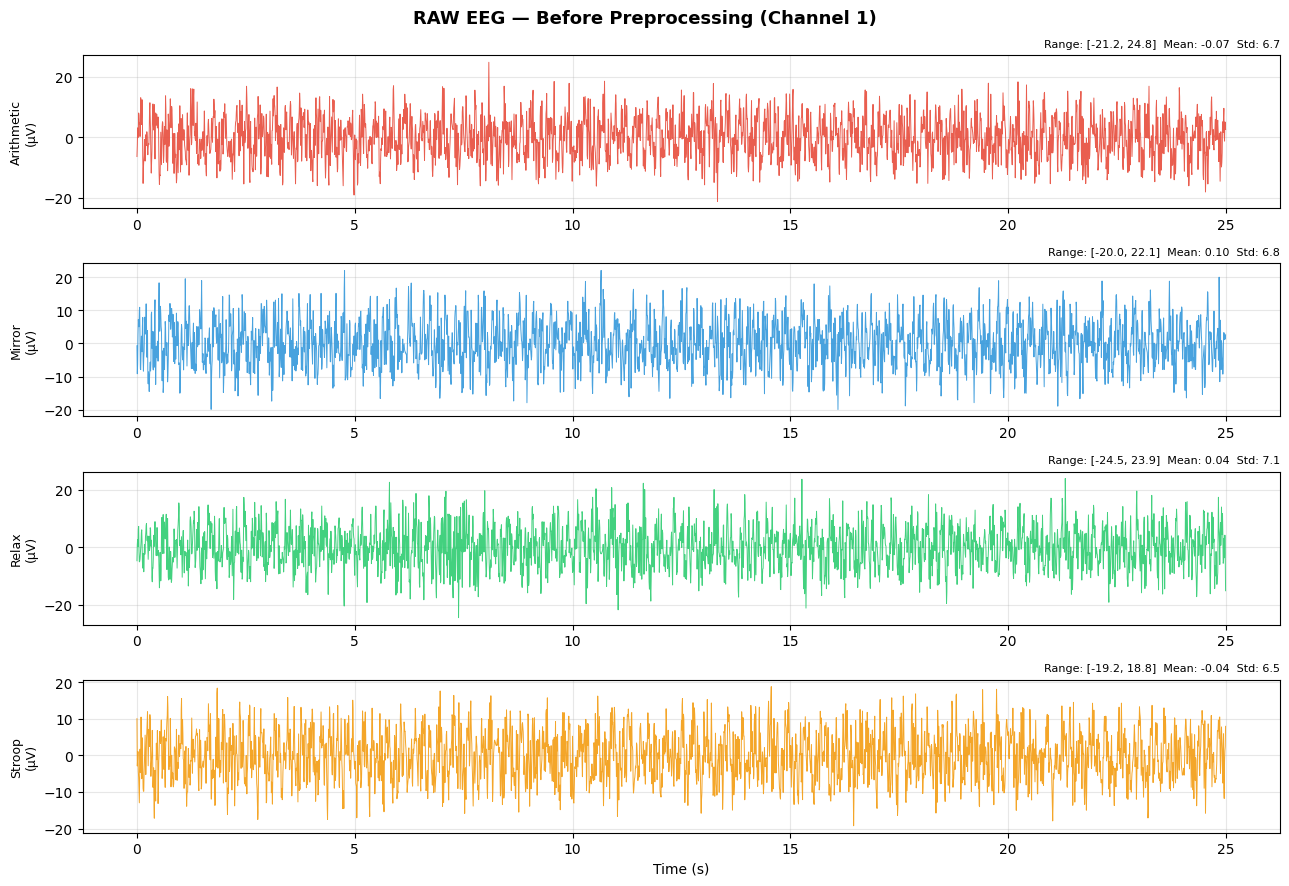

✅ Raw EEG plotted with all 4 tasks


In [25]:
# <-- Changed to 4 rows, and made the figure slightly taller (9)
fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=False)
fig.suptitle('RAW EEG — Before Preprocessing (Channel 1)',
             fontsize=13, fontweight='bold')

for i, (name, color) in enumerate(zip(TASK_NAMES, TASK_COLORS)):
    idx = np.where(y_raw == i)[0][0]
    raw = X_raw[idx][:, 0]
    t   = np.arange(len(raw)) / FS
    axes[i].plot(t, raw, color=color, lw=0.7, alpha=0.9)
    axes[i].set_ylabel(f'{name}\n(µV)', fontsize=9)
    axes[i].grid(alpha=0.3)
    axes[i].set_title(
        f'Range: [{raw.min():.1f}, {raw.max():.1f}]  '
        f'Mean: {raw.mean():.2f}  Std: {raw.std():.1f}',
        fontsize=8, loc='right')

axes[-1].set_xlabel('Time (s)', fontsize=10)
plt.tight_layout()

plt.savefig('raw_eeg_4tasks.png', dpi=110, bbox_inches='tight')
plt.show()
print('✅ Raw EEG plotted with all 4 tasks')

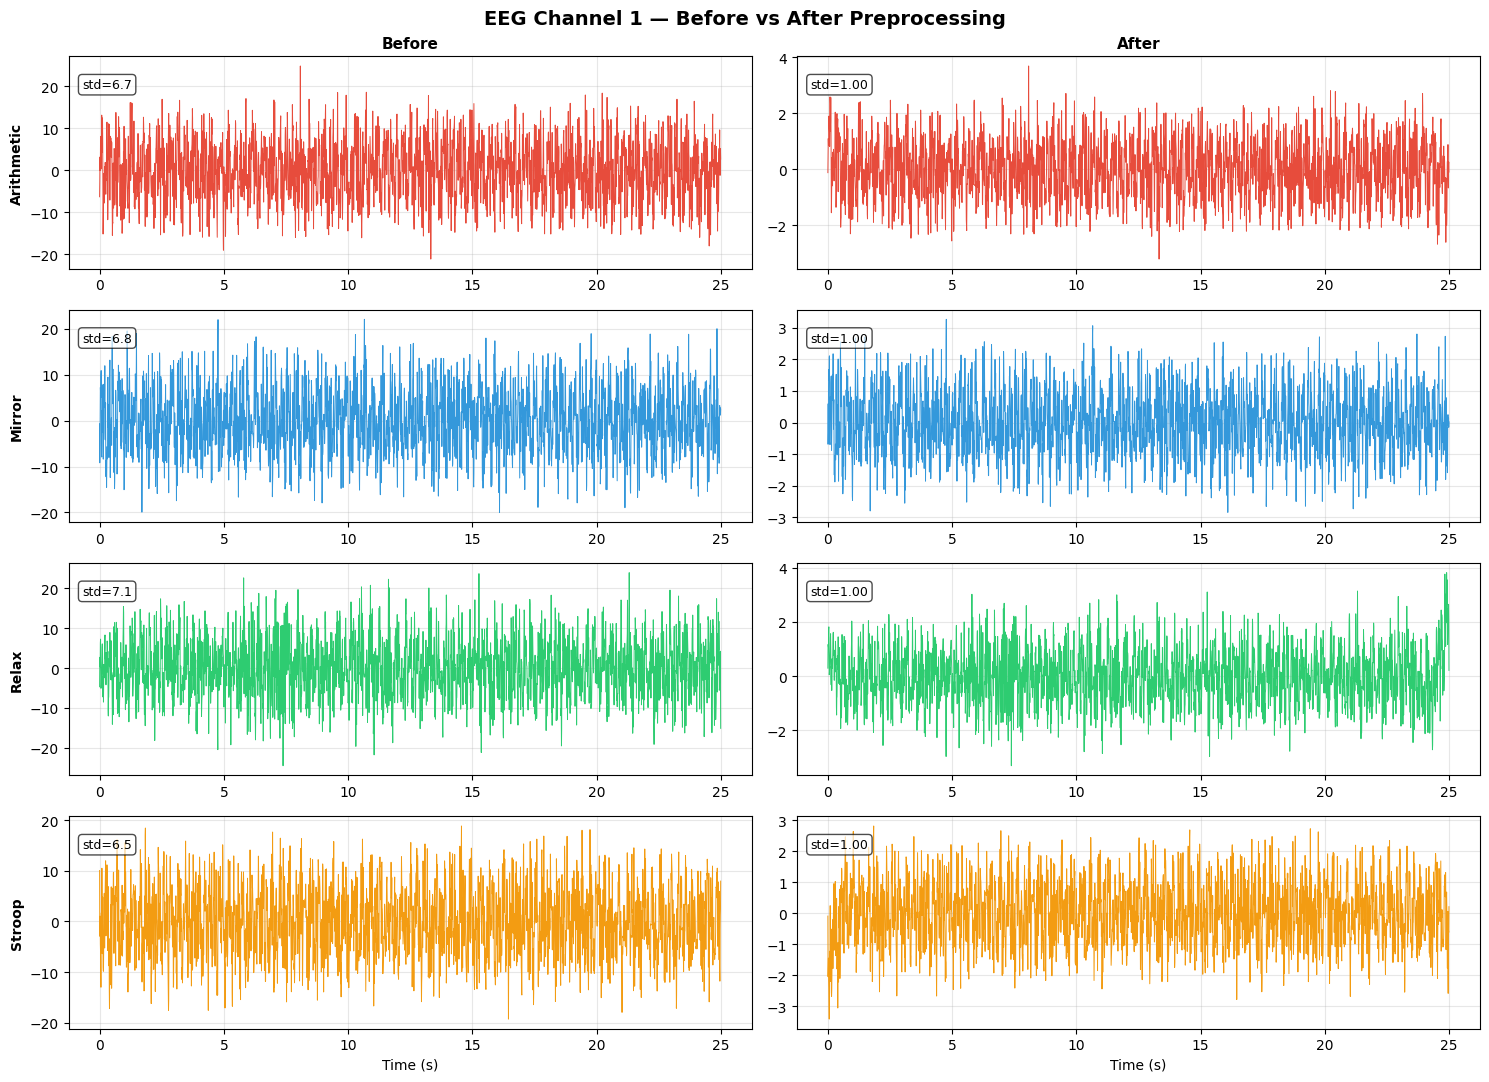

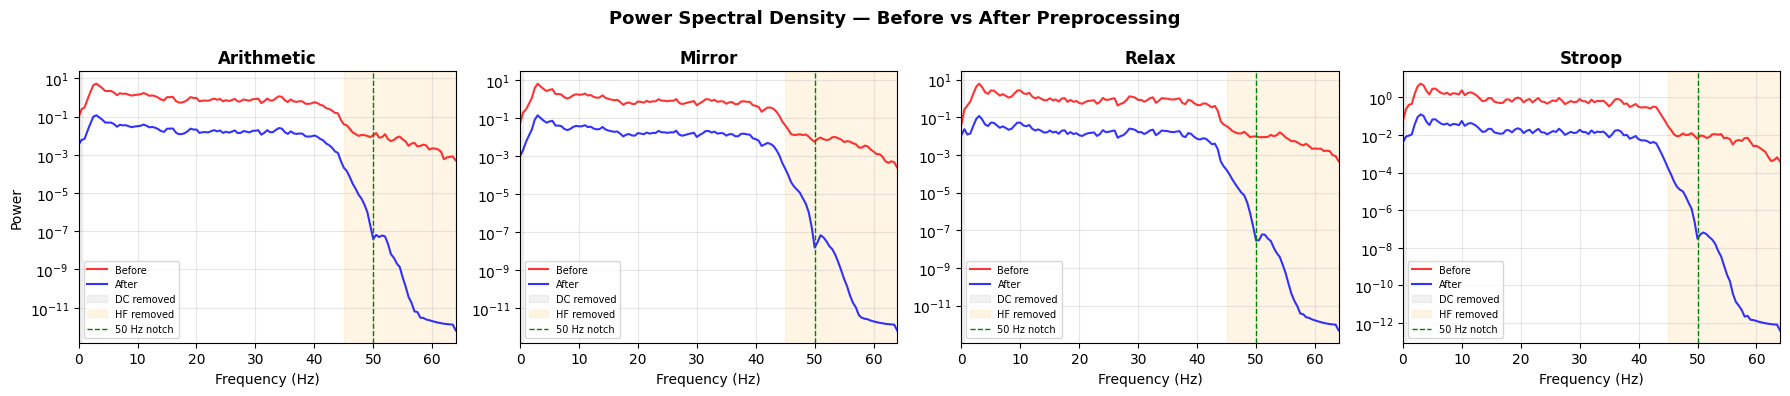

✅ Before / After visualization done with 4 tasks


In [26]:
def bandpass(data, lo=0.5, hi=45.0, fs=FS, order=4):
    # 🛠️ THE FIX: Convert generic object arrays into pure 64-bit numbers
    data = np.asarray(data, dtype=np.float64)
    
    nyq  = fs / 2.0
    b, a = sig.butter(order, [lo/nyq, hi/nyq], btype='band')
    return sig.filtfilt(b, a, data, axis=0)

def notch(data, freq=50.0, fs=FS, Q=30):
    b, a = sig.iirnotch(freq / (fs/2.0), Q)
    return sig.filtfilt(b, a, data, axis=0)

def znorm(data):
    mu  = data.mean(axis=0, keepdims=True)
    std = data.std(axis=0,  keepdims=True) + 1e-8
    return (data - mu) / std

def preprocess(data):
    return znorm(notch(bandpass(data)))

def make_epochs(data, length=EPOCH_LEN):
    return [data[s:s+length] for s in range(0, data.shape[0]-length+1, length)]



# ── Before vs After waveform ──────────────────────────────────────────────────
# Changed from (3, 2) to (4, 2) and made the figure slightly taller (11)
fig, axes = plt.subplots(4, 2, figsize=(15, 11))
fig.suptitle('EEG Channel 1 — Before vs After Preprocessing',
             fontsize=14, fontweight='bold')

for i, (name, color) in enumerate(zip(TASK_NAMES, TASK_COLORS)):
    idx   = np.where(y_raw == i)[0][0]
    raw   = X_raw[idx][:, 0]
    clean = preprocess(X_raw[idx])[:, 0]
    t     = np.arange(len(raw)) / FS

    axes[i, 0].plot(t, raw,   color=color, lw=0.7)
    axes[i, 0].set_ylabel(name, fontsize=10, fontweight='bold')
    axes[i, 0].set_title('Before' if i == 0 else '', fontsize=11, fontweight='bold')
    axes[i, 0].grid(alpha=0.3)
    axes[i, 0].annotate(f'std={raw.std():.1f}', xy=(0.02, 0.85),
                         xycoords='axes fraction', fontsize=9,
                         bbox=dict(boxstyle='round', fc='white', alpha=0.7))

    axes[i, 1].plot(t[:len(clean)], clean, color=color, lw=0.7)
    axes[i, 1].set_title('After' if i == 0 else '', fontsize=11, fontweight='bold')
    axes[i, 1].grid(alpha=0.3)
    axes[i, 1].annotate(f'std={clean.std():.2f}', xy=(0.02, 0.85),
                         xycoords='axes fraction', fontsize=9,
                         bbox=dict(boxstyle='round', fc='white', alpha=0.7))

for ax in axes[-1]: ax.set_xlabel('Time (s)', fontsize=10)
plt.tight_layout()
# Fixed path for local PC
plt.savefig('before_after_waveform_4tasks.png', dpi=110, bbox_inches='tight')
plt.show()

# ── Before vs After PSD ──────────────────────────────────────────────────────
# Changed from (1, 3) to (1, 4) and made the figure wider (18)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Power Spectral Density — Before vs After Preprocessing',
             fontsize=13, fontweight='bold')

for i, (name, color) in enumerate(zip(TASK_NAMES, TASK_COLORS)):
    idx   = np.where(y_raw == i)[0][0]
    raw   = X_raw[idx][:, 0]
    clean = preprocess(X_raw[idx])[:, 0]
    f_r, p_r = sig.welch(raw,   fs=FS, nperseg=256)
    f_c, p_c = sig.welch(clean, fs=FS, nperseg=256)
    
    axes[i].semilogy(f_r, p_r, 'r-', lw=1.5, label='Before', alpha=0.8)
    axes[i].semilogy(f_c, p_c, 'b-', lw=1.5, label='After',  alpha=0.8)
    axes[i].axvspan(0,  0.5, alpha=0.10, color='gray',   label='DC removed')
    axes[i].axvspan(45, 64,  alpha=0.10, color='orange', label='HF removed')
    axes[i].axvline(50, color='green', lw=1, ls='--', label='50 Hz notch')
    
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Frequency (Hz)')
    if i == 0: axes[i].set_ylabel('Power')
    axes[i].set_xlim([0, 64])
    axes[i].legend(fontsize=7)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
# Fixed path for local PC
plt.savefig('before_after_psd_4tasks.png', dpi=110, bbox_inches='tight')
plt.show()
print('✅ Before / After visualization done with 4 tasks')

In [27]:
print('Preprocessing and epoching all signals...')
X_epochs, y_epochs, subj_epochs = [], [], []

for data, label, subj in zip(X_raw, y_raw, subj_raw):
    cleaned = preprocess(data)
    for ep in make_epochs(cleaned):
        X_epochs.append(ep)
        y_epochs.append(label)
        subj_epochs.append(subj)

X_epochs    = np.array(X_epochs)
y_epochs    = np.array(y_epochs)
subj_epochs = np.array(subj_epochs)

print(f'✅ Total epochs: {len(X_epochs)}')
print(f'   Shape       : {X_epochs[0].shape}  ({EPOCH_SEC}s × {X_epochs[0].shape[1]} channels)')
for i, n in enumerate(TASK_NAMES):
    print(f'   {n}: {(y_epochs==i).sum()} epochs')

Preprocessing and epoching all signals...
✅ Total epochs: 2880
   Shape       : (512, 32)  (4s × 32 channels)
   Arithmetic: 720 epochs
   Mirror: 720 epochs
   Relax: 720 epochs
   Stroop: 720 epochs


In [28]:
from joblib import Parallel, delayed

BANDS = {
    'delta': (0.5,  4),
    'theta': (4,    8),
    'alpha': (8,   13),
    'beta' : (13,  30),
    'gamma': (30,  45),
}

def bandpower(ch_data, fs, flo, fhi):
    f, pxx = sig.welch(ch_data, fs=fs, nperseg=min(len(ch_data), 256))
    mask   = (f >= flo) & (f <= fhi)
    # 🛠️ THE FIX: Changed 'trapz' to 'trapezoid' for NumPy 2.0+ compatibility
    return np.trapezoid(pxx[mask], f[mask]) if mask.sum() > 0 else 0.0

def extract_features(ep, fs=FS):
    n_ch  = ep.shape[1]
    feats = []
    bp    = {}

    for band, (lo, hi) in BANDS.items():
        ch_bp = np.array([bandpower(ep[:, c], fs, lo, hi) for c in range(n_ch)])
        bp[band] = ch_bp
        feats.append(ch_bp)

    eps = 1e-10
    feats.append(bp['theta'] / (bp['alpha'] + eps))              # theta/alpha
    feats.append(bp['beta']  / (bp['alpha'] + eps))              # beta/alpha
    feats.append((bp['theta'] + bp['alpha']) / (bp['beta'] + eps))  # engagement

    feats.append(ep.mean(axis=0))
    feats.append(ep.std(axis=0))
    feats.append(skew(ep,     axis=0))
    feats.append(kurtosis(ep, axis=0))

    stft_e = []
    for c in range(min(n_ch, 8)):
        _, _, Zxx = sig.stft(ep[:, c], fs=fs, nperseg=64, noverlap=48)
        stft_e.append((np.abs(Zxx)**2).mean())
    feats.append(np.array([np.mean(stft_e), np.std(stft_e),
                            np.max(stft_e),  np.min(stft_e),
                            np.sum(stft_e)]))

    fvec = np.concatenate(feats)
    fvec = np.where(np.isnan(fvec) | np.isinf(fvec), 0.0, fvec)
    return fvec

print('🚀 Extracting features using ALL CPU cores... (Hold on tight!)')
t0 = time.time()

# Multi-core processing
X_feat_list = Parallel(n_jobs=-1, verbose=10)(
    delayed(extract_features)(ep) for ep in X_epochs
)

X_feat = np.array(X_feat_list, dtype=np.float32)
print(f'\n✅ Feature matrix: {X_feat.shape}  [Finished in {time.time()-t0:.0f}s]')

# Clean + Scale
X_feat   = SimpleImputer(strategy='median').fit_transform(X_feat)
X_scaled = StandardScaler().fit_transform(X_feat)
print('✅ Cleaned and scaled')

🚀 Extracting features using ALL CPU cores... (Hold on tight!)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:    9.7s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  


✅ Feature matrix: (2880, 389)  [Finished in 86s]
✅ Cleaned and scaled


[Parallel(n_jobs=-1)]: Done 2880 out of 2880 | elapsed:  1.4min finished


🤖 Training and evaluating 5 Machine Learning models... (This might take a moment)
Model                | Mean Accuracy   | Std Dev   
-----------------------------------------------------
SVM (Linear)         |        36.70% | ±2.84%
SVM (RBF)            |        39.13% | ±0.36%
KNN                  |        29.17% | ±0.80%
Random Forest        |        34.72% | ±1.61%
MLP                  |        36.25% | ±2.02%

🏆 All models trained in 65.7s!


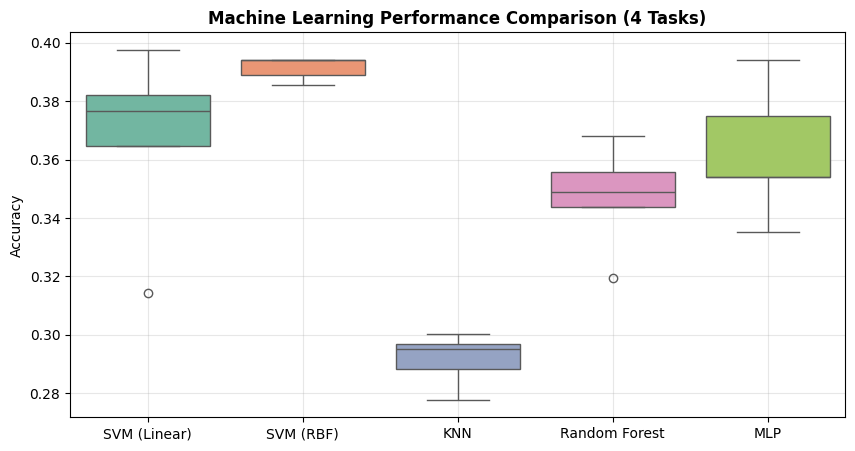

In [29]:
print('🤖 Training and evaluating 5 Machine Learning models... (This might take a moment)')
t0 = time.time()

# Define the 5 models we listed in the config
models = {
    'SVM (Linear)': SVC(kernel='linear', C=1.0, random_state=SEED),
    'SVM (RBF)'   : SVC(kernel='rbf', C=1.0, random_state=SEED),
    'KNN'         : KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'MLP'         : MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=SEED)
}

# Setup cross-validation (5 folds means testing on 5 different mixed batches)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

print(f"{'Model':<20} | {'Mean Accuracy':<15} | {'Std Dev':<10}")
print("-" * 53)

for name, model in models.items():
    # Evaluate the model using cross-validation scores
    scores = cross_val_score(model, X_scaled, y_epochs, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f"{name:<20} | {scores.mean()*100:>12.2f}% | ±{scores.std()*100:.2f}%")

print(f'\n🏆 All models trained in {time.time()-t0:.1f}s!')

# Plot the comparison chart
plt.figure(figsize=(10, 5))
sns.boxplot(data=pd.DataFrame(results), palette="Set2")
plt.title('Machine Learning Performance Comparison (4 Tasks)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=10)
plt.grid(alpha=0.3)
plt.savefig('model_comparison.png', dpi=110, bbox_inches='tight')
plt.show()

─── Split: Subject-wise ───────────────────────────────
 🚀 Train set: 2304 epochs (32 subjects)
 🎯 Test set : 576 epochs (8 subjects)
    Isolated Test Subjects: [5, 13, 16, 17, 20, 27, 28, 38]

Model              | Accuracy | F1-Score
-------------------------------------------
SVM (Linear)       |   38.89% |   38.97%
SVM (RBF)          |   36.11% |   35.76%
KNN                |   28.99% |   28.86%
Random Forest      |   34.38% |   34.05%
MLP                |   35.59% |   35.16%


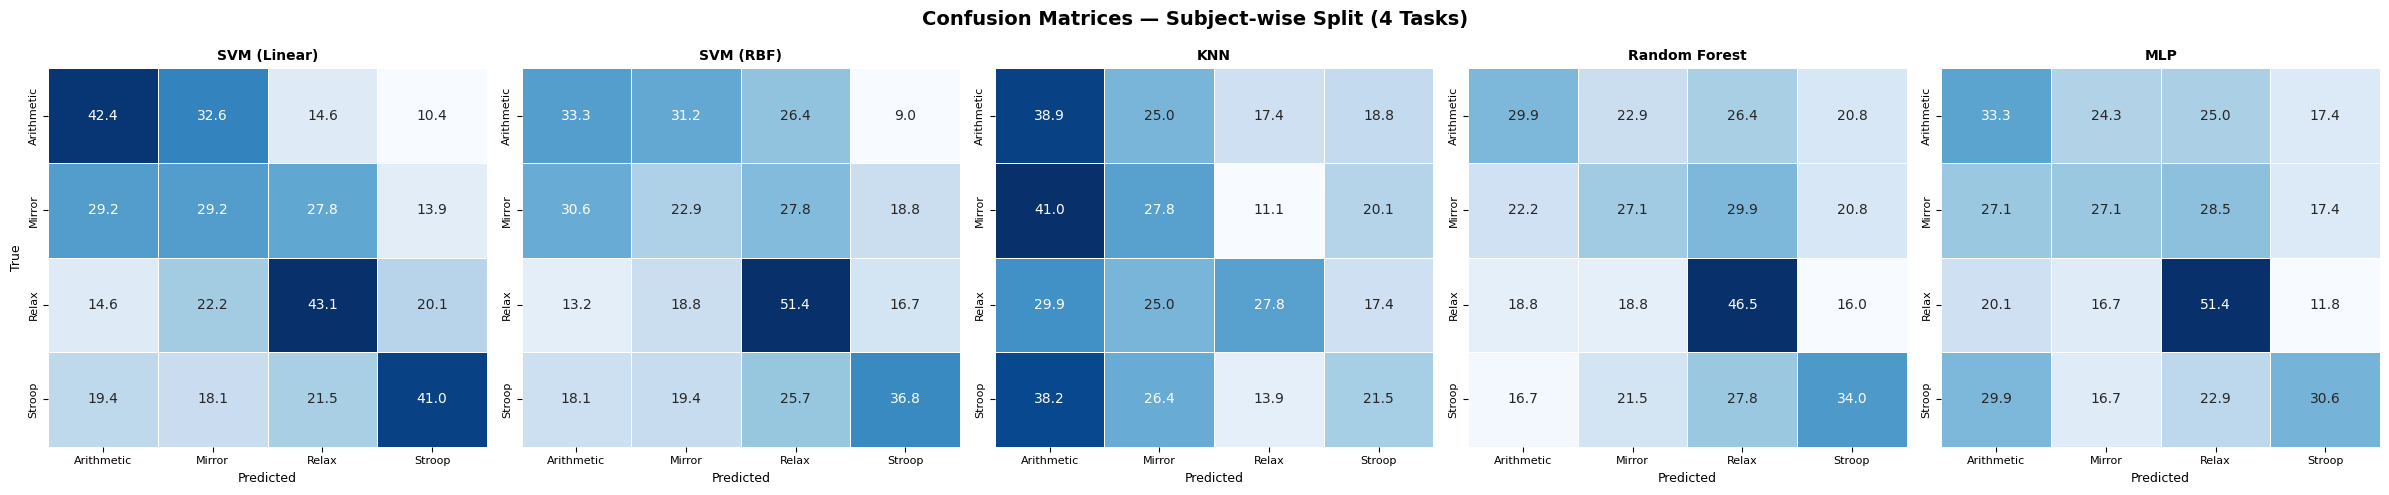


✅ Subject-wise training completed and matrices plotted!


In [30]:
# ── 1. Create the Subject-wise Split ──────────────────────────────────────────
unique_subjs = np.unique(subj_epochs)
np.random.seed(SEED)
perm = np.random.permutation(unique_subjs)

# Hold out exactly 20% of the subjects for testing
n_test_subj  = max(1, int(0.20 * len(unique_subjs)))
test_subjs   = perm[:n_test_subj]
train_subjs  = perm[n_test_subj:]

# Create masks to separate train and test data based on subject IDs
sw_tr_mask = np.isin(subj_epochs, train_subjs)
sw_te_mask = np.isin(subj_epochs, test_subjs)

X_train, y_train = X_scaled[sw_tr_mask], y_epochs[sw_tr_mask]
X_test,  y_test  = X_scaled[sw_te_mask], y_epochs[sw_te_mask]

print('─── Split: Subject-wise ───────────────────────────────')
print(f' 🚀 Train set: {X_train.shape[0]} epochs ({len(train_subjs)} subjects)')
print(f' 🎯 Test set : {X_test.shape[0]} epochs ({len(test_subjs)} subjects)')
print(f'    Isolated Test Subjects: {sorted(test_subjs.tolist())}\n')

# ── 2. Initialize the Models ──────────────────────────────────────────────────
models = {
    'SVM (Linear)': SVC(kernel='linear', C=1.0, random_state=SEED),
    'SVM (RBF)'   : SVC(kernel='rbf', C=10.0, gamma='scale', random_state=SEED),
    'KNN'         : KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15, random_state=SEED, n_jobs=-1),
    'MLP'         : MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=SEED, early_stopping=True)
}

# ── 3. Train and Evaluate ─────────────────────────────────────────────────────
print(f"{'Model':<18} | {'Accuracy':<8} | {'F1-Score':<8}")
print("-" * 43)

predictions = {}
for name, clf in models.items():
    # Train the model on the training subjects
    clf.fit(X_train, y_train)
    
    # Test the model on the completely unseen subjects
    y_pred = clf.predict(X_test)
    predictions[name] = y_pred
    
    acc = accuracy_score(y_test, y_pred) * 100
    f1  = f1_score(y_test, y_pred, average='macro') * 100
    print(f"{name:<18} | {acc:>7.2f}% | {f1:>7.2f}%")

# ── 4. Plot Confusion Matrices for All Models ─────────────────────────────────
# Setup a row of 5 plots (one for each model)
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
fig.suptitle('Confusion Matrices — Subject-wise Split (4 Tasks)', fontsize=14, fontweight='bold')

for i, (name, y_pred) in enumerate(predictions.items()):
    # Calculate confusion matrix percentages
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=TASK_NAMES, yticklabels=TASK_NAMES,
                ax=axes[i], linewidths=0.5, cbar=False)
    
    axes[i].set_title(f"{name}", fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=9)
    if i == 0:
        axes[i].set_ylabel('True', fontsize=9)
    axes[i].tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('subject_wise_confusion_matrices.png', dpi=110, bbox_inches='tight')
plt.show()
print('\n✅ Subject-wise training completed and matrices plotted!')

In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 0 — Imports & shared helpers
# ══════════════════════════════════════════════════════════════════════════════
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.neural_network  import MLPClassifier
from sklearn.metrics         import (accuracy_score, f1_score,
                                      precision_score, recall_score,
                                      confusion_matrix)
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# ── Model factory (called fresh for every fold) ───────────────────────────────
def make_models():
    return {
        'SVM (Linear)' : SVC(kernel='linear', C=1.0,  random_state=SEED),
        'SVM (RBF)'    : SVC(kernel='rbf',    C=10.0, gamma='scale', random_state=SEED),
        'KNN'          : KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
        'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15,
                                                random_state=SEED, n_jobs=-1),
        'MLP'          : MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=400,
                                       random_state=SEED, early_stopping=True),
    }

MODEL_NAMES = list(make_models().keys())
print('✅ Imports & helpers ready')

✅ Imports & helpers ready


In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Stratified K-Fold (k = 5 & k = 10)
# ══════════════════════════════════════════════════════════════════════════════

def run_kfold(X, y, k=5, seed=SEED):
    """
    Run Stratified K-Fold for all models.
    Returns a dict  model_name -> list of per-fold dicts
    (keys: accuracy, f1, precision, recall, cm).
    """
    skf     = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
    results = {name: [] for name in make_models()}

    for fold_idx, (tr, te) in enumerate(skf.split(X, y), 1):
        X_tr, X_te = X[tr], X[te]
        y_tr, y_te = y[tr], y[te]

        # ── scale INSIDE the fold (no leakage) ─────────────────────────────
        scaler    = StandardScaler()
        X_tr_s    = scaler.fit_transform(X_tr)
        X_te_s    = scaler.transform(X_te)

        for name, clf in make_models().items():
            clf.fit(X_tr_s, y_tr)
            y_pred = clf.predict(X_te_s)
            results[name].append({
                'fold'     : fold_idx,
                'accuracy' : accuracy_score(y_te, y_pred),
                'f1'       : f1_score(y_te, y_pred, average='macro', zero_division=0),
                'precision': precision_score(y_te, y_pred, average='macro', zero_division=0),
                'recall'   : recall_score(y_te, y_pred, average='macro', zero_division=0),
                'cm'       : confusion_matrix(y_te, y_pred),
            })
        print(f'  Fold {fold_idx}/{k} done')

    return results


def summarise_kfold(results, k, label=''):
    """Print a tidy summary table for K-Fold results."""
    print(f'\n{'═'*60}')
    print(f'  {label}  —  {k}-Fold Stratified Cross-Validation')
    print(f'{'═'*60}')
    print(f"{'Model':<18} | {'Acc (%)':<10} | {'F1 (%)':<10} | {'Prec (%)':<10} | {'Rec (%)'}")
    print(f"{'─'*18}-+-{'─'*10}-+-{'─'*10}-+-{'─'*10}-+-{'─'*10}")
    summary = {}
    for name, folds in results.items():
        accs = [f['accuracy']  for f in folds]
        f1s  = [f['f1']        for f in folds]
        pres = [f['precision'] for f in folds]
        recs = [f['recall']    for f in folds]
        summary[name] = {'acc': accs, 'f1': f1s, 'precision': pres, 'recall': recs}
        print(f"{name:<18} | "
              f"{np.mean(accs)*100:>6.2f}±{np.std(accs)*100:.2f}  | "
              f"{np.mean(f1s)*100:>6.2f}±{np.std(f1s)*100:.2f}  | "
              f"{np.mean(pres)*100:>6.2f}±{np.std(pres)*100:.2f}  | "
              f"{np.mean(recs)*100:>6.2f}±{np.std(recs)*100:.2f}")
    return summary


# ── NOTE: if X_scaled still contains any NaN/Inf from earlier pipeline ────────
#          re-impute here so the fold-level scaler works cleanly.
X_clean = SimpleImputer(strategy='median').fit_transform(X_scaled)

# ── Run 5-Fold ────────────────────────────────────────────────────────────────
print('🚀 Running 5-Fold Stratified CV …')
t0 = time.time()
kf5_results  = run_kfold(X_clean, y_epochs, k=5)
kf5_summary  = summarise_kfold(kf5_results,  k=5,  label='K-Fold (k=5)')
print(f'\n⏱  5-Fold done in {time.time()-t0:.1f}s')

# ── Run 10-Fold ───────────────────────────────────────────────────────────────
print('\n🚀 Running 10-Fold Stratified CV …')
t0 = time.time()
kf10_results = run_kfold(X_clean, y_epochs, k=10)
kf10_summary = summarise_kfold(kf10_results, k=10, label='K-Fold (k=10)')
print(f'\n⏱  10-Fold done in {time.time()-t0:.1f}s')

🚀 Running 5-Fold Stratified CV …
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

════════════════════════════════════════════════════════════
  K-Fold (k=5)  —  5-Fold Stratified Cross-Validation
════════════════════════════════════════════════════════════
Model              | Acc (%)    | F1 (%)     | Prec (%)   | Rec (%)
──────────────────-+-──────────-+-──────────-+-──────────-+-──────────
SVM (Linear)       |  36.63±2.84  |  36.77±2.77  |  37.26±2.69  |  36.63±2.84
SVM (RBF)          |  38.26±1.11  |  38.24±0.96  |  38.37±0.77  |  38.26±1.11
KNN                |  28.99±0.79  |  28.90±0.90  |  31.01±0.97  |  28.99±0.79
Random Forest      |  36.32±1.50  |  36.16±1.58  |  36.23±1.66  |  36.32±1.50
MLP                |  36.98±2.46  |  36.62±2.53  |  36.78±2.36  |  36.98±2.46

⏱  5-Fold done in 179.3s

🚀 Running 10-Fold Stratified CV …
  Fold 1/10 done
  Fold 2/10 done
  Fold 3/10 done
  Fold 4/10 done
  Fold 5/10 done
  Fold 6/10 done
  Fold 7/10 done
 

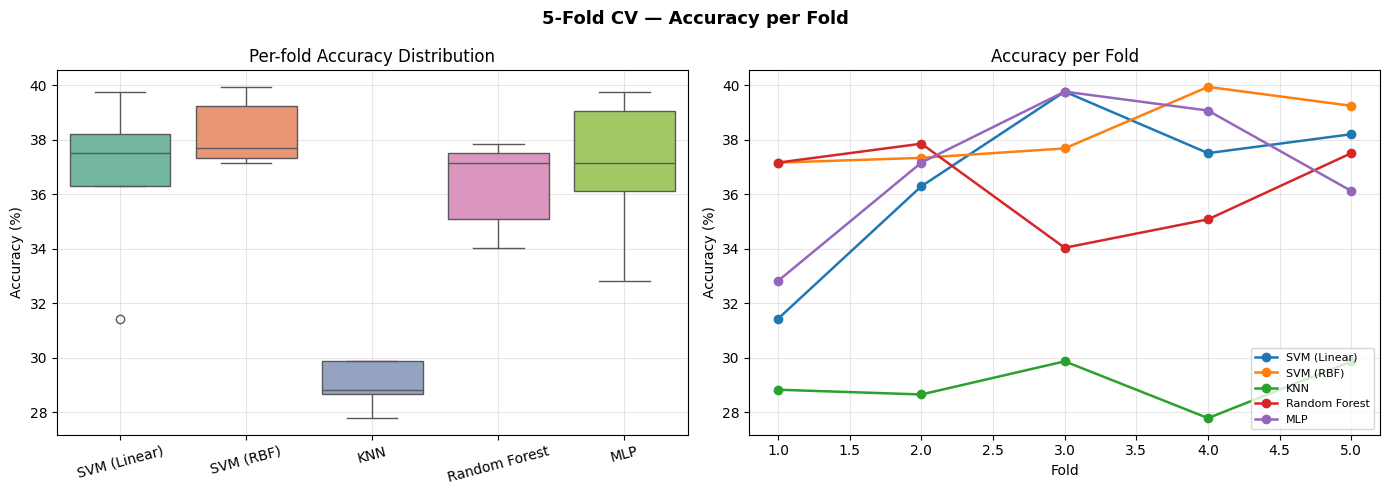

✅ Saved → kfold5_boxplot.png


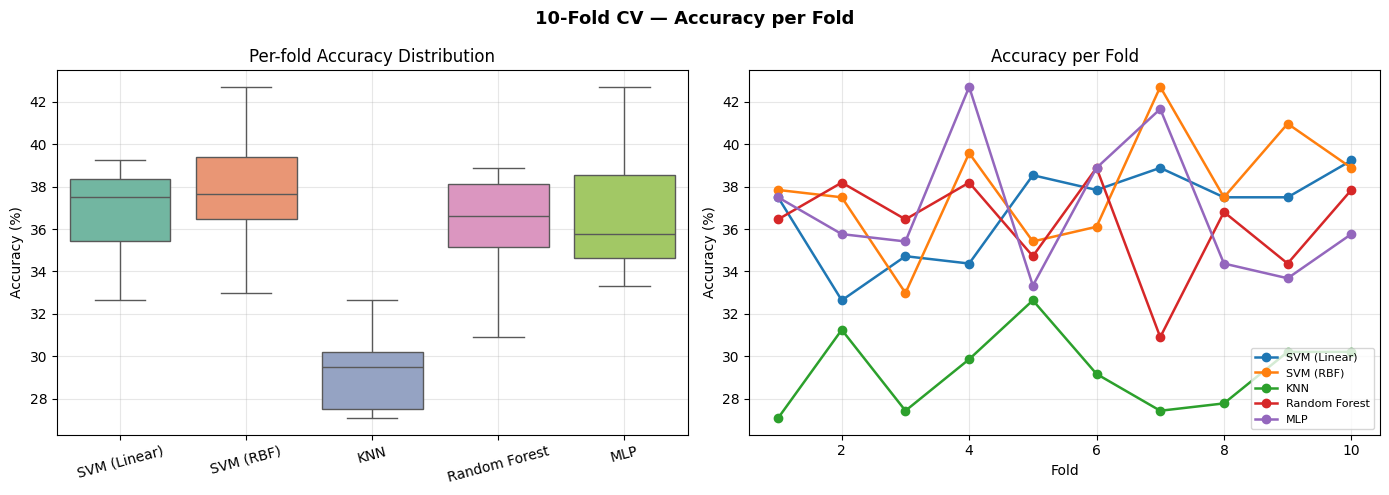

✅ Saved → kfold10_boxplot.png


In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Plot K-Fold results: boxplots + per-fold accuracy line
# ══════════════════════════════════════════════════════════════════════════════

def plot_kfold_boxplot(results_dict, title, fname):
    """Boxplot of per-fold accuracy for every model."""
    data = {name: [f['accuracy']*100 for f in folds]
            for name, folds in results_dict.items()}
    df = pd.DataFrame(data)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # ── Left: boxplot ─────────────────────────────────────────────────────────
    sns.boxplot(data=df, palette='Set2', ax=axes[0])
    axes[0].set_ylabel('Accuracy (%)', fontsize=10)
    axes[0].set_title('Per-fold Accuracy Distribution')
    axes[0].grid(alpha=0.3)
    for tick in axes[0].get_xticklabels():
        tick.set_rotation(15)

    # ── Right: line plot (fold-by-fold) ──────────────────────────────────────
    colors = plt.cm.tab10.colors
    for i, (name, vals) in enumerate(data.items()):
        axes[1].plot(range(1, len(vals)+1), vals, marker='o',
                     label=name, color=colors[i], lw=1.8)
    axes[1].set_xlabel('Fold')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy per Fold')
    axes[1].legend(fontsize=8, loc='lower right')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(fname, dpi=110, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved → {fname}')


plot_kfold_boxplot(kf5_results,  '5-Fold CV — Accuracy per Fold',  'kfold5_boxplot.png')
plot_kfold_boxplot(kf10_results, '10-Fold CV — Accuracy per Fold', 'kfold10_boxplot.png')

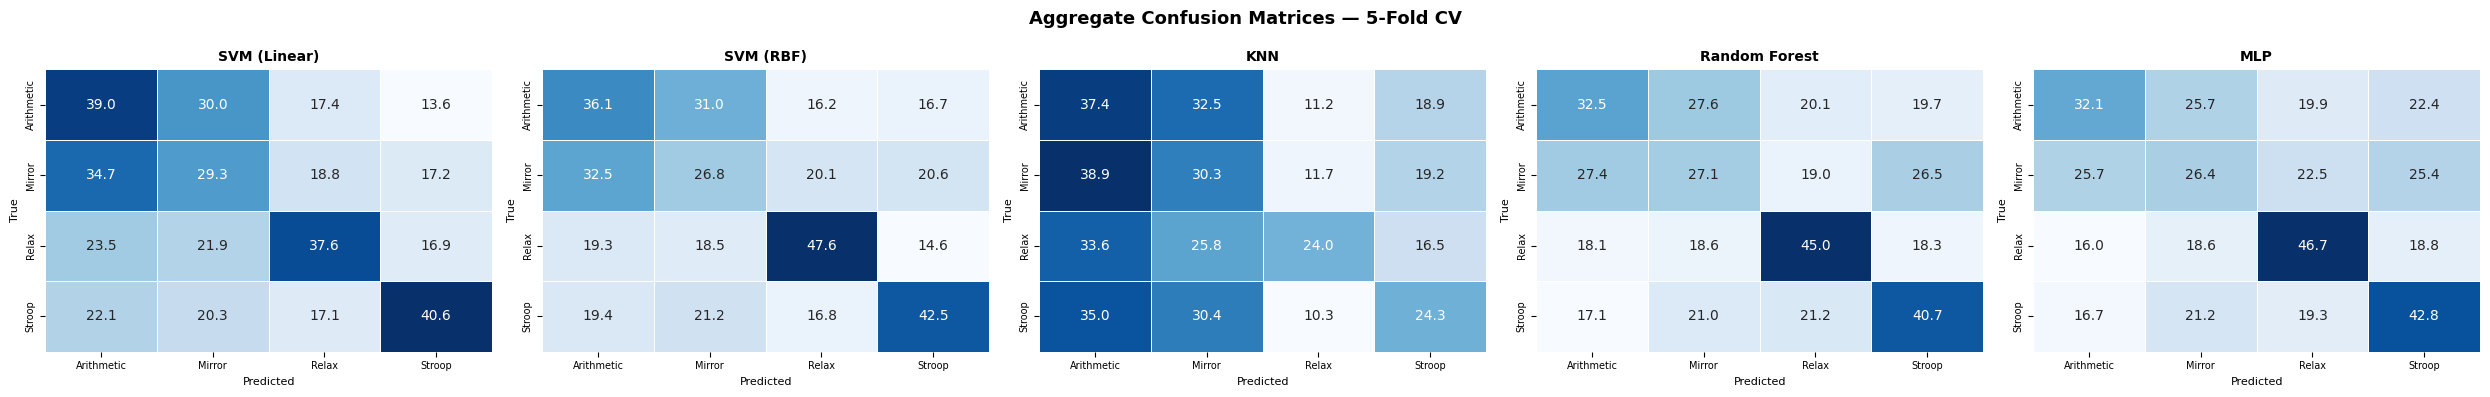

✅ Saved → kfold5_confusion_matrices.png


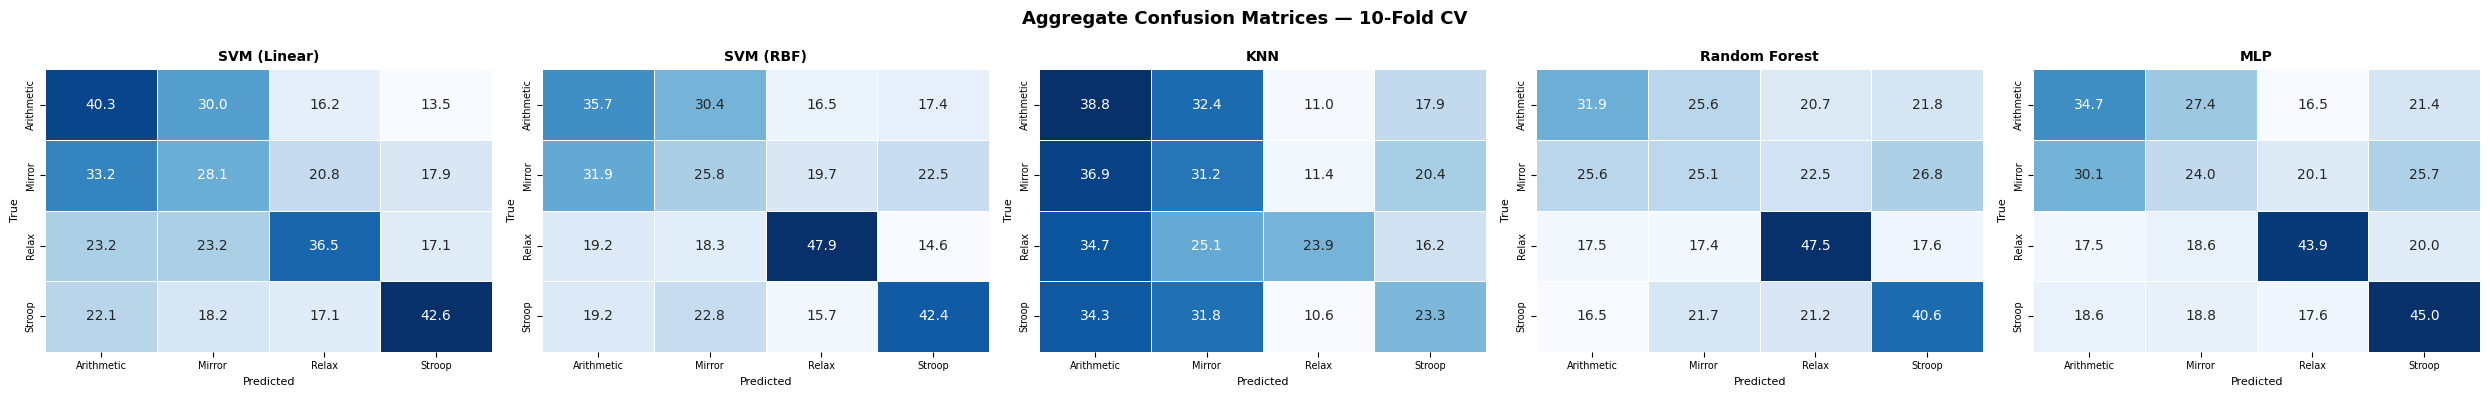

✅ Saved → kfold10_confusion_matrices.png


In [34]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Aggregate Confusion Matrices for K-Fold
# ══════════════════════════════════════════════════════════════════════════════

def plot_aggregate_cm(results_dict, task_names, title, fname):
    """
    Sum confusion matrices across all folds, then normalise row-wise
    to get per-class accuracy percentages.
    """
    n_models = len(results_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    if n_models == 1:
        axes = [axes]

    for ax, (name, folds) in zip(axes, results_dict.items()):
        cm_sum = sum(f['cm'] for f in folds).astype(float)
        cm_pct = cm_sum / cm_sum.sum(axis=1, keepdims=True) * 100

        sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                    xticklabels=task_names, yticklabels=task_names,
                    ax=ax, linewidths=0.5, cbar=False)
        ax.set_title(name, fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=8)
        ax.set_ylabel('True', fontsize=8)
        ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.savefig(fname, dpi=110, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved → {fname}')


plot_aggregate_cm(kf5_results,  TASK_NAMES,
                  'Aggregate Confusion Matrices — 5-Fold CV',
                  'kfold5_confusion_matrices.png')

plot_aggregate_cm(kf10_results, TASK_NAMES,
                  'Aggregate Confusion Matrices — 10-Fold CV',
                  'kfold10_confusion_matrices.png')

In [35]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — LOSO cross-validation
# ══════════════════════════════════════════════════════════════════════════════

def run_loso(X, y, groups):
    """
    Leave-One-Subject-Out cross-validation.

    Parameters
    ----------
    X      : feature matrix  (n_epochs × n_features)
    y      : labels          (n_epochs,)
    groups : subject IDs     (n_epochs,)

    Returns
    -------
    results : dict  model_name -> list of per-subject dicts
    """
    logo    = LeaveOneGroupOut()
    unique  = np.unique(groups)
    n_subj  = len(unique)
    results = {name: [] for name in make_models()}

    print(f'  Total subjects (folds): {n_subj}')
    print(f'  Unique subjects       : {sorted(unique.tolist())}\n')

    for fold_idx, (tr, te) in enumerate(logo.split(X, y, groups), 1):
        left_out_subj = np.unique(groups[te])[0]

        X_tr, X_te = X[tr], X[te]
        y_tr, y_te = y[tr], y[te]

        # ── skip if test set has fewer than 2 unique classes ─────────────────
        if len(np.unique(y_te)) < 2:
            print(f'  [S{left_out_subj}] skip — single class in test fold')
            continue

        # ── scale inside the fold (fit on train only) ─────────────────────────
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        for name, clf in make_models().items():
            clf.fit(X_tr_s, y_tr)
            y_pred = clf.predict(X_te_s)
            results[name].append({
                'subject'  : left_out_subj,
                'fold'     : fold_idx,
                'n_test'   : len(y_te),
                'accuracy' : accuracy_score(y_te, y_pred),
                'f1'       : f1_score(y_te, y_pred, average='macro', zero_division=0),
                'precision': precision_score(y_te, y_pred, average='macro', zero_division=0),
                'recall'   : recall_score(y_te, y_pred, average='macro', zero_division=0),
                'cm'       : confusion_matrix(y_te, y_pred,
                                              labels=np.unique(y)),
            })

        best = max(results, key=lambda m: results[m][-1]['accuracy'])
        print(f'  S{left_out_subj:02d} ({fold_idx:2d}/{n_subj}) '
              f'| n_test={len(y_te):4d} '
              f'| best={best} '
              f'acc={results[best][-1]["accuracy"]*100:.1f}%')

    return results


def summarise_loso(results, label='LOSO'):
    print(f'\n{"═"*65}')
    print(f'  {label} — Leave-One-Subject-Out Cross-Validation')
    print(f'{"═"*65}')
    print(f"{'Model':<18} | {'Acc (%)':<12} | {'F1 (%)':<12} | {'Prec (%)':<12} | {'Rec (%)'}")
    print(f"{'─'*18}-+-{'─'*12}-+-{'─'*12}-+-{'─'*12}-+-{'─'*12}")
    summary = {}
    for name, folds in results.items():
        accs = [f['accuracy']  for f in folds]
        f1s  = [f['f1']        for f in folds]
        pres = [f['precision'] for f in folds]
        recs = [f['recall']    for f in folds]
        summary[name] = {'acc': accs, 'f1': f1s, 'precision': pres, 'recall': recs}
        print(f"{name:<18} | "
              f"{np.mean(accs)*100:>7.2f}±{np.std(accs)*100:.2f}   | "
              f"{np.mean(f1s)*100:>7.2f}±{np.std(f1s)*100:.2f}   | "
              f"{np.mean(pres)*100:>7.2f}±{np.std(pres)*100:.2f}   | "
              f"{np.mean(recs)*100:>7.2f}±{np.std(recs)*100:.2f}")
    return summary


print('🚀 Running LOSO cross-validation … (one fold per subject)')
t0 = time.time()
loso_results = run_loso(X_clean, y_epochs, subj_epochs)
loso_summary = summarise_loso(loso_results)
print(f'\n⏱  LOSO done in {time.time()-t0:.1f}s')

🚀 Running LOSO cross-validation … (one fold per subject)
  Total subjects (folds): 40
  Unique subjects       : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]

  S01 ( 1/40) | n_test=  72 | best=MLP acc=37.5%
  S02 ( 2/40) | n_test=  72 | best=SVM (Linear) acc=44.4%
  S03 ( 3/40) | n_test=  72 | best=MLP acc=51.4%
  S04 ( 4/40) | n_test=  72 | best=SVM (Linear) acc=34.7%
  S05 ( 5/40) | n_test=  72 | best=Random Forest acc=45.8%
  S06 ( 6/40) | n_test=  72 | best=MLP acc=40.3%
  S07 ( 7/40) | n_test=  72 | best=SVM (RBF) acc=44.4%
  S08 ( 8/40) | n_test=  72 | best=MLP acc=44.4%
  S09 ( 9/40) | n_test=  72 | best=MLP acc=38.9%
  S10 (10/40) | n_test=  72 | best=SVM (Linear) acc=47.2%
  S11 (11/40) | n_test=  72 | best=SVM (Linear) acc=31.9%
  S12 (12/40) | n_test=  72 | best=SVM (Linear) acc=36.1%
  S13 (13/40) | n_test=  72 | best=SVM (Linear) acc=44.4%
  S14 (14/40) | n_test=  72 

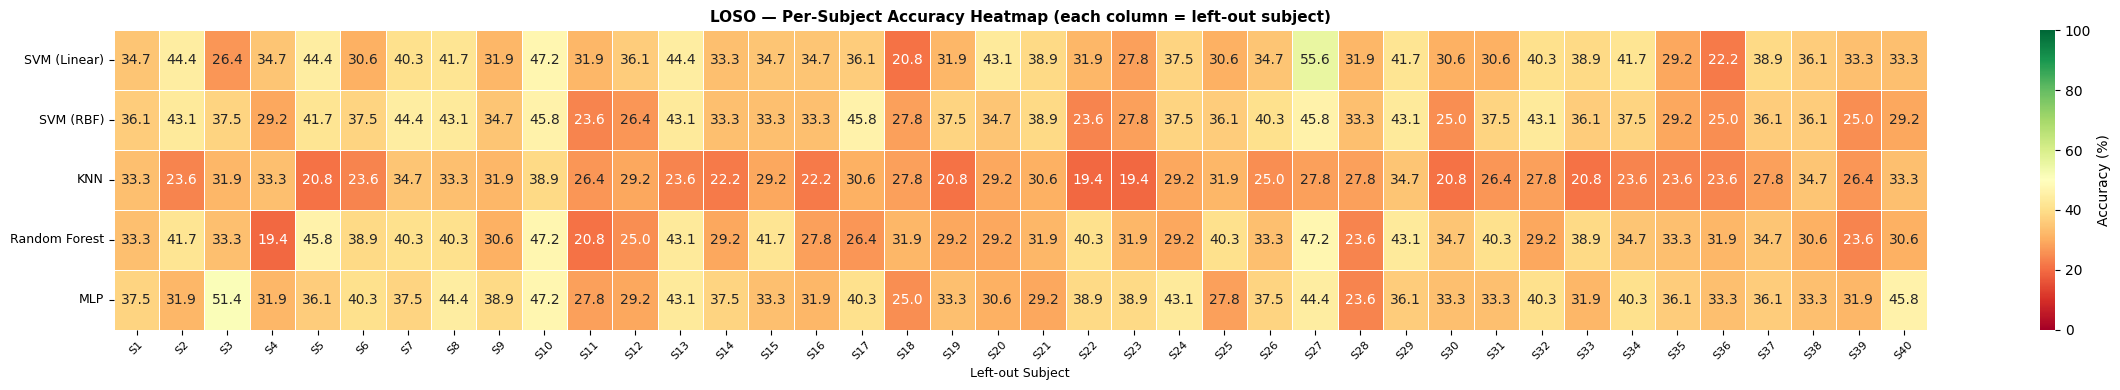

✅ Saved → loso_subject_heatmap.png


In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — LOSO: per-subject accuracy heatmap
# ══════════════════════════════════════════════════════════════════════════════

def plot_loso_heatmap(results, fname='loso_subject_heatmap.png'):
    """
    Row = model, Column = subject.
    Cell value = accuracy (%) for that leave-one-out fold.
    """
    subjects = sorted({f['subject'] for folds in results.values() for f in folds})
    model_names = list(results.keys())

    mat = np.full((len(model_names), len(subjects)), np.nan)
    for mi, name in enumerate(model_names):
        for fold in results[name]:
            si = subjects.index(fold['subject'])
            mat[mi, si] = fold['accuracy'] * 100

    fig, ax = plt.subplots(figsize=(max(10, len(subjects)*0.6), 4))
    sns.heatmap(mat,
                xticklabels=[f'S{s}' for s in subjects],
                yticklabels=model_names,
                annot=True, fmt='.1f', cmap='RdYlGn',
                vmin=0, vmax=100, linewidths=0.4,
                cbar_kws={'label': 'Accuracy (%)'},
                ax=ax)
    ax.set_title('LOSO — Per-Subject Accuracy Heatmap (each column = left-out subject)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Left-out Subject', fontsize=9)
    ax.tick_params(axis='x', labelsize=8, rotation=45)
    ax.tick_params(axis='y', labelsize=9)
    plt.tight_layout()
    plt.savefig(fname, dpi=110, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved → {fname}')


plot_loso_heatmap(loso_results)

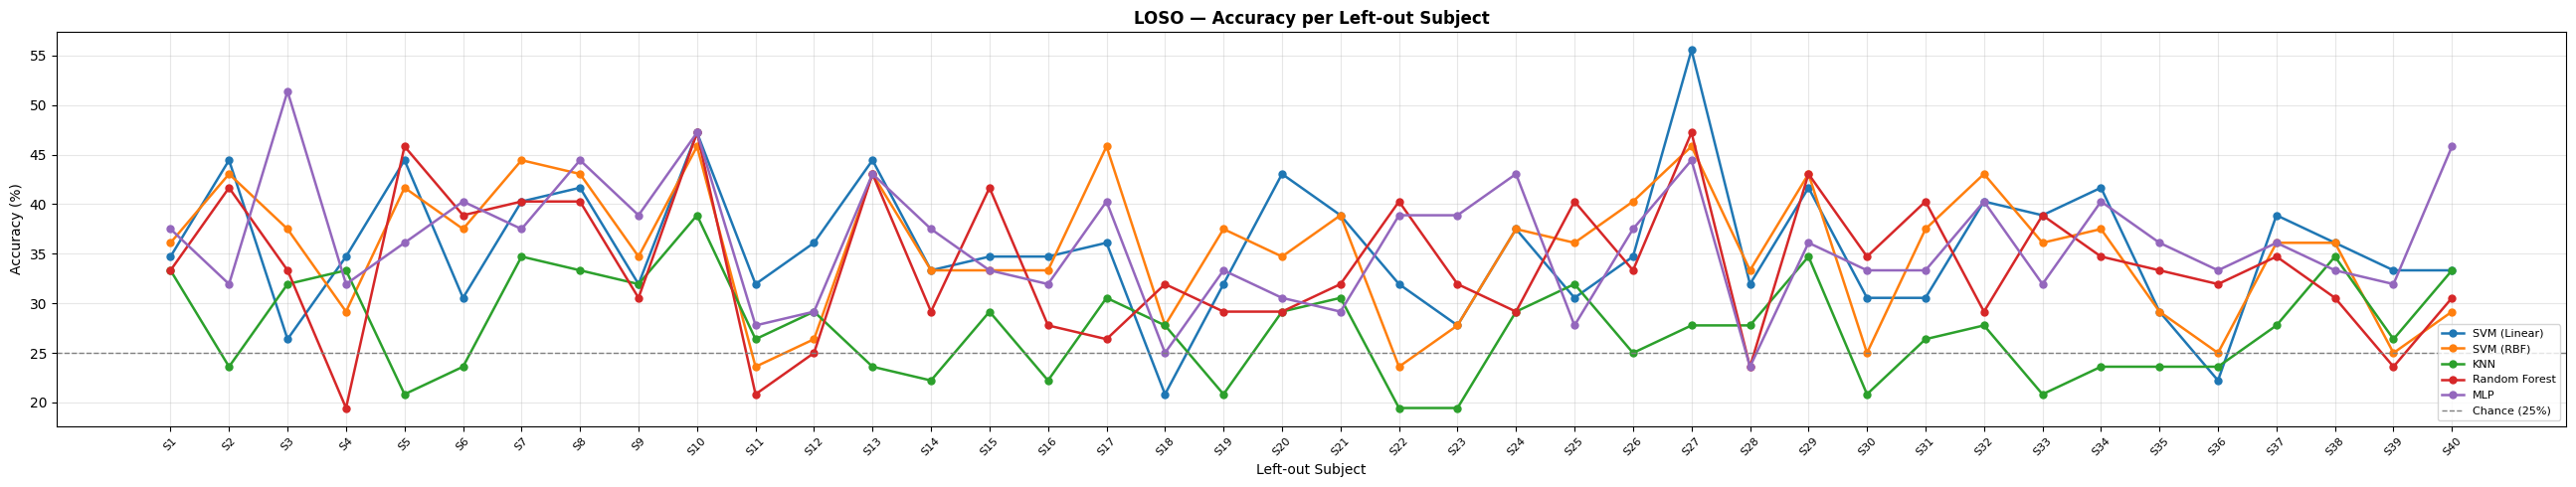

✅ Saved → loso_subject_lineplot.png


In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — LOSO: per-subject accuracy line plot
# ══════════════════════════════════════════════════════════════════════════════

def plot_loso_lineplot(results, fname='loso_subject_lineplot.png'):
    subjects = sorted({f['subject'] for folds in results.values() for f in folds})
    colors   = plt.cm.tab10.colors

    fig, ax = plt.subplots(figsize=(max(10, len(subjects)*0.65), 5))
    for i, (name, folds) in enumerate(results.items()):
        fold_map = {f['subject']: f['accuracy']*100 for f in folds}
        ys = [fold_map.get(s, np.nan) for s in subjects]
        ax.plot(subjects, ys, marker='o', label=name,
                color=colors[i], lw=1.8, markersize=5)

    ax.axhline(25, color='gray', ls='--', lw=1, label='Chance (25%)')
    ax.set_xlabel('Left-out Subject', fontsize=10)
    ax.set_ylabel('Accuracy (%)', fontsize=10)
    ax.set_title('LOSO — Accuracy per Left-out Subject', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_xticks(subjects)
    ax.set_xticklabels([f'S{s}' for s in subjects], rotation=45, fontsize=8)
    plt.tight_layout()
    plt.savefig(fname, dpi=110, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved → {fname}')


plot_loso_lineplot(loso_results)

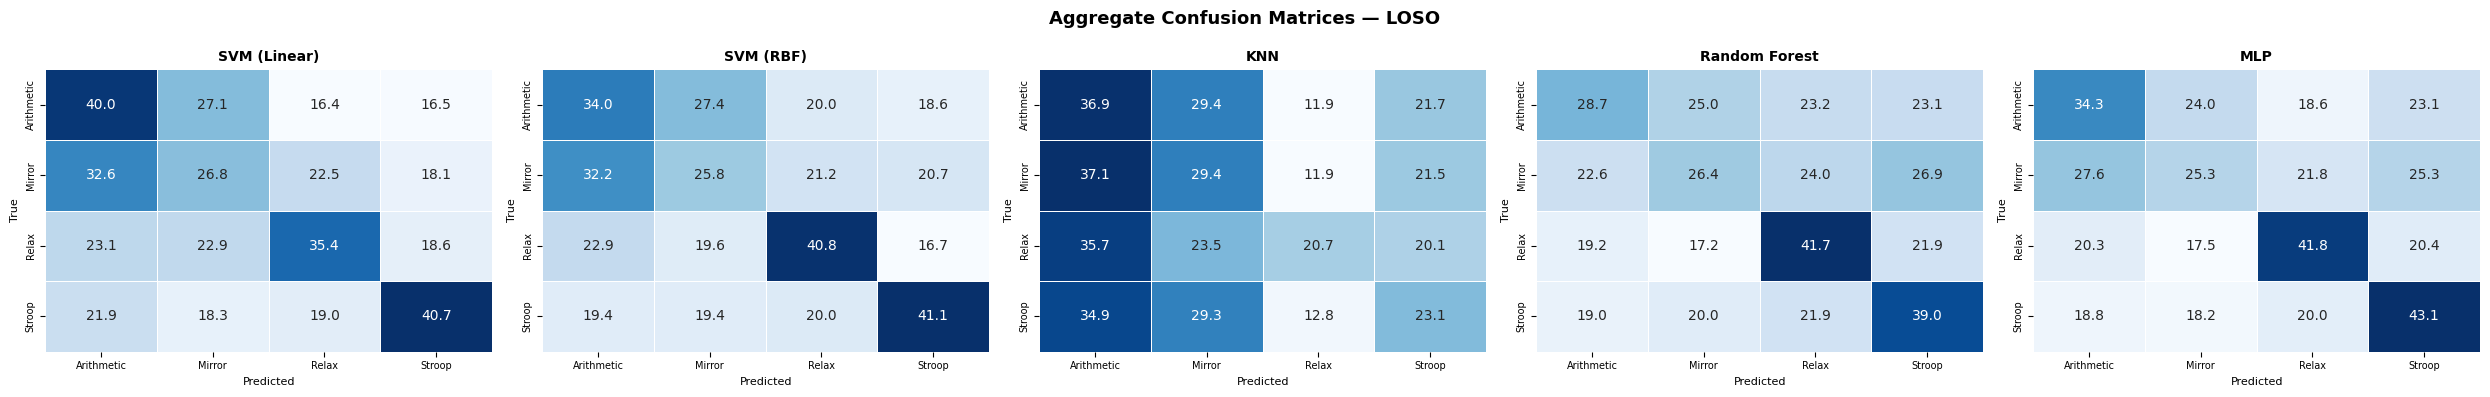

✅ Saved → loso_confusion_matrices.png


In [38]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — LOSO: Aggregate Confusion Matrices
# ══════════════════════════════════════════════════════════════════════════════

plot_aggregate_cm(loso_results, TASK_NAMES,
                  'Aggregate Confusion Matrices — LOSO',
                  'loso_confusion_matrices.png')

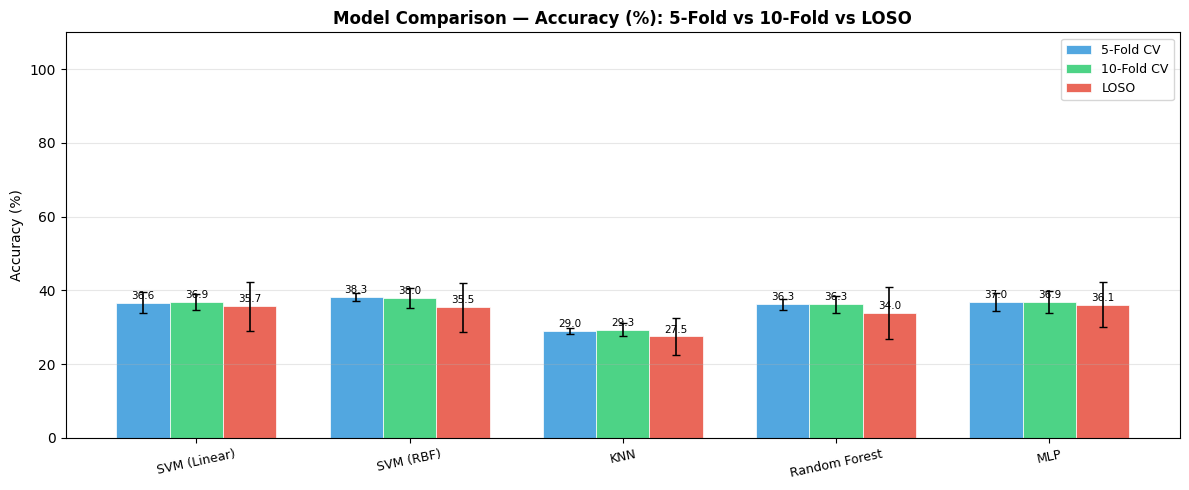

✅ Saved → comparison_accuracy.png


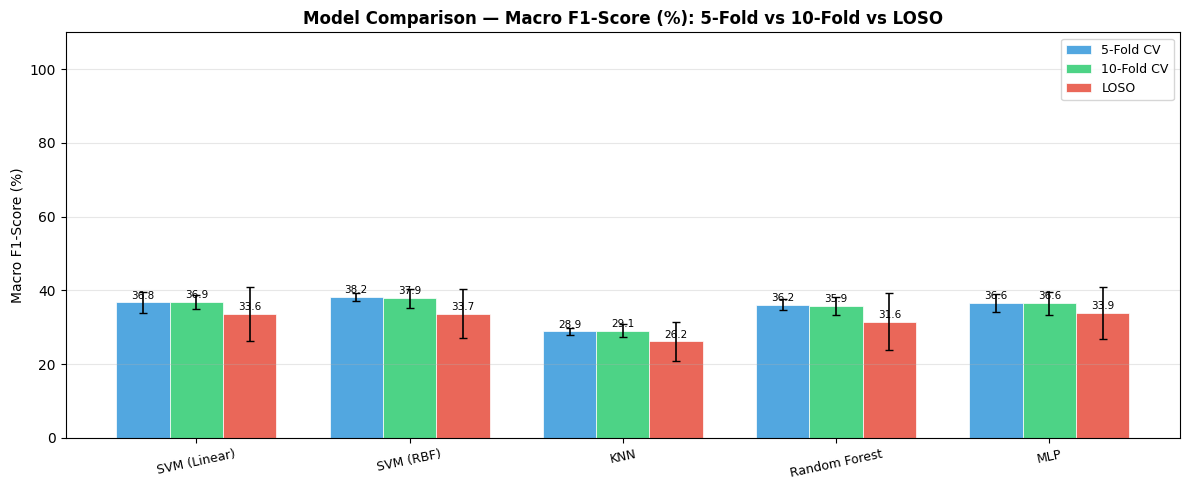

✅ Saved → comparison_f1.png


In [39]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Comparison bar chart (K-Fold 5 vs K-Fold 10 vs LOSO)
# ══════════════════════════════════════════════════════════════════════════════

def comparison_bar(kf5_sum, kf10_sum, loso_sum,
                   metric='acc', label='Accuracy (%)',
                   fname='comparison_bar.png'):
    model_names = list(kf5_sum.keys())
    n = len(model_names)
    x = np.arange(n)
    w = 0.25

    fig, ax = plt.subplots(figsize=(12, 5))

    for i, (tag, summary, color) in enumerate([
            ('5-Fold CV',  kf5_sum,  '#3498DB'),
            ('10-Fold CV', kf10_sum, '#2ECC71'),
            ('LOSO',       loso_sum, '#E74C3C')]):
        means  = np.array([np.mean(summary[m][metric])*100 for m in model_names])
        stds   = np.array([np.std(summary[m][metric])*100  for m in model_names])
        bars = ax.bar(x + i*w, means, w, label=tag, color=color,
                      alpha=0.85, edgecolor='white', linewidth=0.6)
        ax.errorbar(x + i*w, means, yerr=stds, fmt='none',
                    color='black', capsize=3, lw=1.2)
        for bar, val in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x + w)
    ax.set_xticklabels(model_names, rotation=12, fontsize=9)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f'Model Comparison — {label}: 5-Fold vs 10-Fold vs LOSO',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 110)
    plt.tight_layout()
    plt.savefig(fname, dpi=110, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved → {fname}')


comparison_bar(kf5_summary, kf10_summary, loso_summary,
               metric='acc', label='Accuracy (%)',
               fname='comparison_accuracy.png')

comparison_bar(kf5_summary, kf10_summary, loso_summary,
               metric='f1', label='Macro F1-Score (%)',
               fname='comparison_f1.png')

In [40]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Full metric table (DataFrame export)
# ══════════════════════════════════════════════════════════════════════════════

rows = []
for method, summary in [('5-Fold', kf5_summary),
                         ('10-Fold', kf10_summary),
                         ('LOSO', loso_summary)]:
    for model, vals in summary.items():
        rows.append({
            'Method'   : method,
            'Model'    : model,
            'Acc_mean' : np.mean(vals['acc'])*100,
            'Acc_std'  : np.std(vals['acc'])*100,
            'F1_mean'  : np.mean(vals['f1'])*100,
            'F1_std'   : np.std(vals['f1'])*100,
            'Prec_mean': np.mean(vals['precision'])*100,
            'Rec_mean' : np.mean(vals['recall'])*100,
        })

df_results = pd.DataFrame(rows).round(2)
df_results.to_csv('sam40_kfold_loso_results.csv', index=False)
print('✅ Full results saved → sam40_kfold_loso_results.csv')
print()
print(df_results.to_string(index=False))

✅ Full results saved → sam40_kfold_loso_results.csv

 Method         Model  Acc_mean  Acc_std  F1_mean  F1_std  Prec_mean  Rec_mean
 5-Fold  SVM (Linear)     36.63     2.84    36.77    2.77      37.26     36.63
 5-Fold     SVM (RBF)     38.26     1.11    38.24    0.96      38.37     38.26
 5-Fold           KNN     28.99     0.79    28.90    0.90      31.01     28.99
 5-Fold Random Forest     36.32     1.50    36.16    1.58      36.23     36.32
 5-Fold           MLP     36.98     2.46    36.62    2.53      36.78     36.98
10-Fold  SVM (Linear)     36.88     2.08    36.87    1.94      37.25     36.88
10-Fold     SVM (RBF)     37.95     2.65    37.91    2.59      38.04     37.95
10-Fold           KNN     29.31     1.77    29.11    1.82      31.23     29.31
10-Fold Random Forest     36.28     2.28    35.88    2.42      35.82     36.28
10-Fold           MLP     36.91     3.08    36.55    3.12      36.79     36.91
   LOSO  SVM (Linear)     35.73     6.68    33.63    7.26      37.92     35.73

In [41]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Best model summary printout
# ══════════════════════════════════════════════════════════════════════════════

print('\n' + '═'*55)
print('  🏆  BEST MODEL PER VALIDATION METHOD')
print('═'*55)



═══════════════════════════════════════════════════════
  🏆  BEST MODEL PER VALIDATION METHOD
═══════════════════════════════════════════════════════


In [42]:
for method in ['5-Fold', '10-Fold', 'LOSO']:
    sub = df_results[df_results['Method'] == method]
    best = sub.loc[sub['Acc_mean'].idxmax()]
    print(f'  {method:<10}: {best["Model"]:<18}  '
          f'Acc={best["Acc_mean"]:.2f}±{best["Acc_std"]:.2f}%  '
          f'F1={best["F1_mean"]:.2f}%')
print('═'*55)

  5-Fold    : SVM (RBF)           Acc=38.26±1.11%  F1=38.24%
  10-Fold   : SVM (RBF)           Acc=37.95±2.65%  F1=37.91%
  LOSO      : MLP                 Acc=36.11±6.05%  F1=33.93%
═══════════════════════════════════════════════════════


In [43]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL A — Extra imports
# ══════════════════════════════════════════════════════════════════════════════
!pip install -q xgboost

import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.signal as sig
from scipy.stats import skew, kurtosis
from joblib import Parallel, delayed

from sklearn.model_selection   import StratifiedKFold, GridSearchCV
from sklearn.preprocessing    import StandardScaler
from sklearn.impute            import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline          import Pipeline
from sklearn.svm               import SVC
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network    import MLPClassifier
from sklearn.metrics           import (accuracy_score, f1_score,
                                        precision_score, recall_score,
                                        confusion_matrix)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not available — skipping it')

warnings.filterwarnings('ignore')
np.random.seed(SEED)
print('✅ Imports done')


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Imports done


In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL B — Re-epoch with 50% overlap
# ══════════════════════════════════════════════════════════════════════════════

# ── Re-use your preprocessing functions from earlier ──────────────────────────
def bandpass(data, lo=0.5, hi=45.0, fs=FS, order=4):
    data = np.asarray(data, dtype=np.float64)
    nyq  = fs / 2.0
    b, a = sig.butter(order, [lo/nyq, hi/nyq], btype='band')
    return sig.filtfilt(b, a, data, axis=0)

def notch(data, freq=50.0, fs=FS, Q=30):
    b, a = sig.iirnotch(freq / (fs/2.0), Q)
    return sig.filtfilt(b, a, data, axis=0)

def znorm(data):
    mu  = data.mean(axis=0, keepdims=True)
    std = data.std(axis=0, keepdims=True) + 1e-8
    return (data - mu) / std

def preprocess(data):
    return znorm(notch(bandpass(data)))

# ── Overlapping epoch maker ───────────────────────────────────────────────────
STEP = EPOCH_LEN    # No overlap

def make_epochs_overlap(data, length=EPOCH_LEN, step=STEP):
    """Slide a window of `length` samples over `data` with `step` stride."""
    return [data[s:s+length]
            for s in range(0, data.shape[0] - length + 1, step)]

print('Re-epoching with 50% overlap …')
X_ov, y_ov, subj_ov = [], [], []

for data, label, subj in zip(X_raw, y_raw, subj_raw):
    cleaned = preprocess(data)
    for ep in make_epochs_overlap(cleaned):
        X_ov.append(ep)
        y_ov.append(label)
        subj_ov.append(subj)

X_ov    = np.array(X_ov)
y_ov    = np.array(y_ov)
subj_ov = np.array(subj_ov)

print(f'✅ Overlapping epochs: {len(X_ov)}  '
      f'(was {len(X_epochs)} non-overlapping)')
for i, n in enumerate(TASK_NAMES):
    print(f'   {n}: {(y_ov==i).sum()} epochs')

NameError: name 'FS' is not defined

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL C — Richer feature extractor
# ══════════════════════════════════════════════════════════════════════════════

BANDS = {
    'delta': (0.5,  4),
    'theta': (4,    8),
    'alpha': (8,   13),
    'beta' : (13,  30),
    'gamma': (30,  45),
}

def bandpower(ch, fs, flo, fhi):
    """Band power via Welch PSD."""
    f, pxx = sig.welch(ch, fs=fs, nperseg=min(len(ch), 256))
    mask   = (f >= flo) & (f <= fhi)
    return np.trapezoid(pxx[mask], f[mask]) if mask.sum() > 0 else 0.0

def differential_entropy(ch, fs, flo, fhi):
    """
    Differential Entropy = 0.5 * log(2πe * variance_of_band_signal).
    Band-pass the channel, then compute variance.
    """
    nyq  = fs / 2.0
    b, a = sig.butter(4, [flo/nyq, fhi/nyq], btype='band')
    try:
        filtered = sig.filtfilt(b, a, ch)
        var = np.var(filtered) + 1e-10
        return 0.5 * np.log(2 * np.pi * np.e * var)
    except:
        return 0.0

def hjorth(ch):
    """Hjorth Activity, Mobility, Complexity."""
    d1  = np.diff(ch)
    d2  = np.diff(d1)
    act = np.var(ch)  + 1e-10
    mob = np.sqrt(np.var(d1) / act)
    com = np.sqrt(np.var(d2) / (np.var(d1) + 1e-10)) / (mob + 1e-10)
    return act, mob, com

def extract_features_rich(ep, fs=FS):
    """
    Full feature vector per epoch:
    - Band power  (5 bands × n_ch)
    - Differential Entropy (5 bands × n_ch)
    - Hjorth params (3 × n_ch)
    - Spectral ratios: theta/alpha, beta/alpha, engagement (3 × n_ch)
    - Time-domain stats: mean, std, skew, kurtosis (4 × n_ch)
    - Inter-channel correlation upper triangle
    - Frontal Alpha Asymmetry (1 scalar, if ≥2 frontal channels)
    """
    n_ch  = ep.shape[1]
    feats = []
    eps   = 1e-10
    bp    = {}

    # ── Band power ────────────────────────────────────────────────────────────
    for band, (lo, hi) in BANDS.items():
        ch_bp = np.array([bandpower(ep[:, c], fs, lo, hi) for c in range(n_ch)])
        bp[band] = ch_bp
        feats.append(ch_bp)

    # ── Differential Entropy ──────────────────────────────────────────────────
    for band, (lo, hi) in BANDS.items():
        de = np.array([differential_entropy(ep[:, c], fs, lo, hi) for c in range(n_ch)])
        feats.append(de)

    # ── Spectral ratios ───────────────────────────────────────────────────────
    feats.append(bp['theta'] / (bp['alpha'] + eps))               # theta/alpha
    feats.append(bp['beta']  / (bp['alpha'] + eps))               # beta/alpha
    feats.append(bp['theta'] / (bp['beta']  + eps))               # theta/beta
    feats.append((bp['theta'] + bp['alpha']) / (bp['beta'] + eps))# engagement

    # ── Hjorth parameters ─────────────────────────────────────────────────────
    hjorth_arr = np.array([hjorth(ep[:, c]) for c in range(n_ch)])  # n_ch × 3
    feats.append(hjorth_arr[:, 0])   # activity
    feats.append(hjorth_arr[:, 1])   # mobility
    feats.append(hjorth_arr[:, 2])   # complexity

    # ── Time-domain statistics ────────────────────────────────────────────────
    feats.append(ep.mean(axis=0))
    feats.append(ep.std(axis=0))
    feats.append(skew(ep, axis=0))
    feats.append(kurtosis(ep, axis=0))

    # ── Inter-channel correlation (upper triangle) ────────────────────────────
    # Use only first 16 channels to keep feature dim manageable
    n_sel = min(n_ch, 16)
    corr  = np.corrcoef(ep[:, :n_sel].T)           # n_sel × n_sel
    triu  = corr[np.triu_indices(n_sel, k=1)]       # n_sel*(n_sel-1)/2 values
    feats.append(triu)

    # ── Frontal Alpha Asymmetry (FAA) ─────────────────────────────────────────
    # SAM40 uses 32-channel cap; F3=channel 3, F4=channel 4 (0-indexed)
    # Adjust indices if your montage differs
    if n_ch >= 5:
        alpha_F3 = bandpower(ep[:, 3], fs, 8, 13) + eps
        alpha_F4 = bandpower(ep[:, 4], fs, 8, 13) + eps
        faa      = np.log(alpha_F4) - np.log(alpha_F3)
        feats.append(np.array([faa]))

    fvec = np.concatenate(feats)
    fvec = np.where(np.isnan(fvec) | np.isinf(fvec), 0.0, fvec)
    return fvec


print(f'🚀 Extracting RICH features (overlapping epochs) …')
t0 = time.time()
X_rich_list = Parallel(n_jobs=-1, verbose=5)(
    delayed(extract_features_rich)(ep) for ep in X_ov
)
X_rich = np.array(X_rich_list, dtype=np.float32)
X_rich = SimpleImputer(strategy='median').fit_transform(X_rich)

print(f'\n✅ Rich feature matrix: {X_rich.shape}  [{time.time()-t0:.0f}s]')
print(f'   Features per epoch: {X_rich.shape[1]}')

🚀 Extracting RICH features (overlapping epochs) …


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   27.5s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   57.3s
[Parallel(n_jobs=-1)]: Done 256 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 616 tasks      | elapsed:  5.2min
[Parallel(n_jobs=-1)]: Done 850 tasks      | elapsed:  7.1min
[Parallel(n_jobs=-1)]: Done 1120 tasks      | elapsed:  9.0min
[Parallel(n_jobs=-1)]: Done 1426 tasks      | elapsed: 10.1min
[Parallel(n_jobs=-1)]: Done 1768 tasks      | elapsed: 10.3min
[Parallel(n_jobs=-1)]: Done 2146 tasks      | elapsed: 10.8min
[Parallel(n_jobs=-1)]: Done 2560 tasks      | elapsed: 11.2min
[Parallel(n_jobs=-1)]: Done 3010 tasks      | elapsed: 11.7min
[Parallel(n_jobs=-1)]: Done 3496 tasks      | elapsed: 12.2min
[Parallel(n_jobs=-1)]: Done 4018 tasks      | elapsed: 12.8min
[Parallel(n_jobs=-1)]: Done 4576 tasks      | e


✅ Rich feature matrix: (5280, 793)  [846s]
   Features per epoch: 793


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL D — Pipelines with feature selection & tuned hyperparameters
# ══════════════════════════════════════════════════════════════════════════════

N_FEATURES = 150   # keep top-150 features; tune this if needed

def make_pipeline(clf):
    return Pipeline([
        ('imputer',  SimpleImputer(strategy='median')),
        ('scaler',   StandardScaler()),
        ('selector', SelectKBest(f_classif, k=N_FEATURES)),
        ('clf',      clf),
    ])


# ── Model zoo (tuned hyperparameters) ─────────────────────────────────────────
PIPELINES = {
    'SVM (Linear)' : make_pipeline(
        SVC(kernel='linear', C=0.5, random_state=SEED, probability=False)),

    'SVM (RBF)'    : make_pipeline(
        SVC(kernel='rbf', C=10.0, gamma='scale', random_state=SEED)),

    'KNN (k=7)'    : make_pipeline(
        KNeighborsClassifier(n_neighbors=7, metric='euclidean', n_jobs=-1)),

    'Random Forest': make_pipeline(
        RandomForestClassifier(n_estimators=300, max_depth=20,
                                min_samples_leaf=2, random_state=SEED, n_jobs=-1)),

    'MLP'          : make_pipeline(
        MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=500,
                       learning_rate_init=0.001, early_stopping=True,
                       random_state=SEED)),

    'Gradient Boost': make_pipeline(
        GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                    learning_rate=0.1, random_state=SEED)),
}

if HAS_XGB:
    PIPELINES['XGBoost'] = make_pipeline(
        XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                       use_label_encoder=False, eval_metric='mlogloss',
                       random_state=SEED, n_jobs=-1))

print(f'✅ {len(PIPELINES)} pipelines ready: {list(PIPELINES.keys())}')

✅ 7 pipelines ready: ['SVM (Linear)', 'SVM (RBF)', 'KNN (k=7)', 'Random Forest', 'MLP', 'Gradient Boost', 'XGBoost']


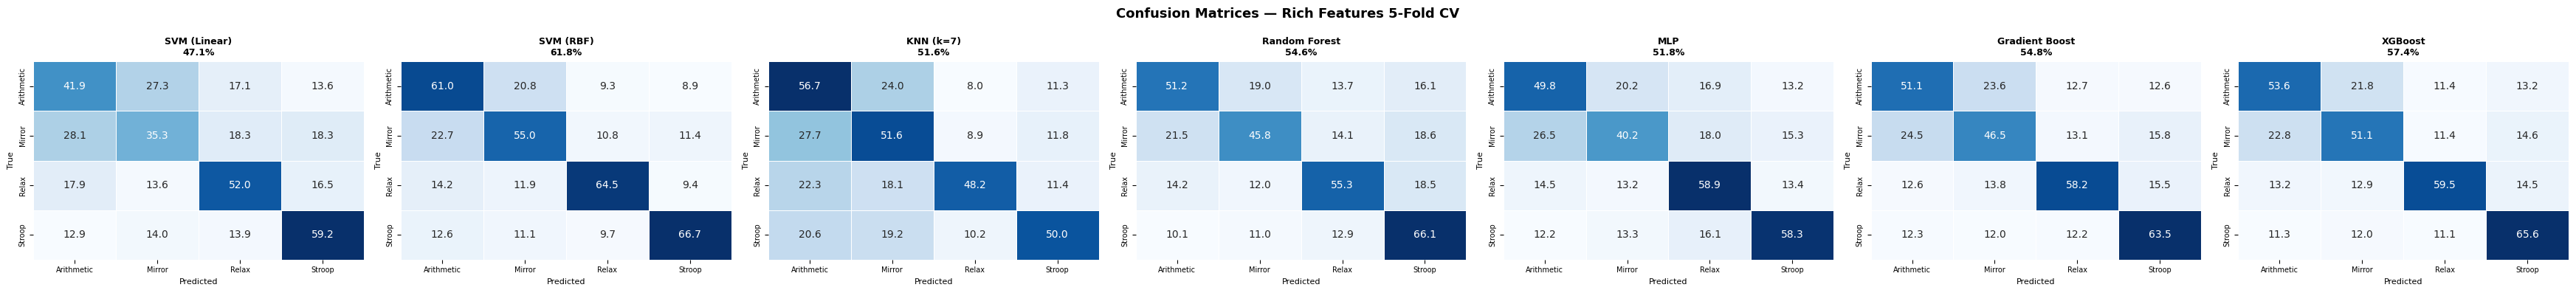

✅ Saved → rich_features_cm.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL F — Confusion matrices for all models
# ══════════════════════════════════════════════════════════════════════════════

n_models = len(cv_results)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
fig.suptitle('Confusion Matrices — Rich Features 5-Fold CV',
             fontsize=13, fontweight='bold')

if n_models == 1:
    axes = [axes]

for ax, (name, folds) in zip(axes, cv_results.items()):
    cm_sum = sum(f['cm'] for f in folds).astype(float)
    cm_pct = cm_sum / cm_sum.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=TASK_NAMES, yticklabels=TASK_NAMES,
                ax=ax, linewidths=0.5, cbar=False)
    acc = np.mean([f['acc'] for f in folds])*100
    ax.set_title(f'{name}\n{acc:.1f}%', fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('rich_features_cm.png', dpi=110, bbox_inches='tight')
plt.show()
print('✅ Saved → rich_features_cm.png')

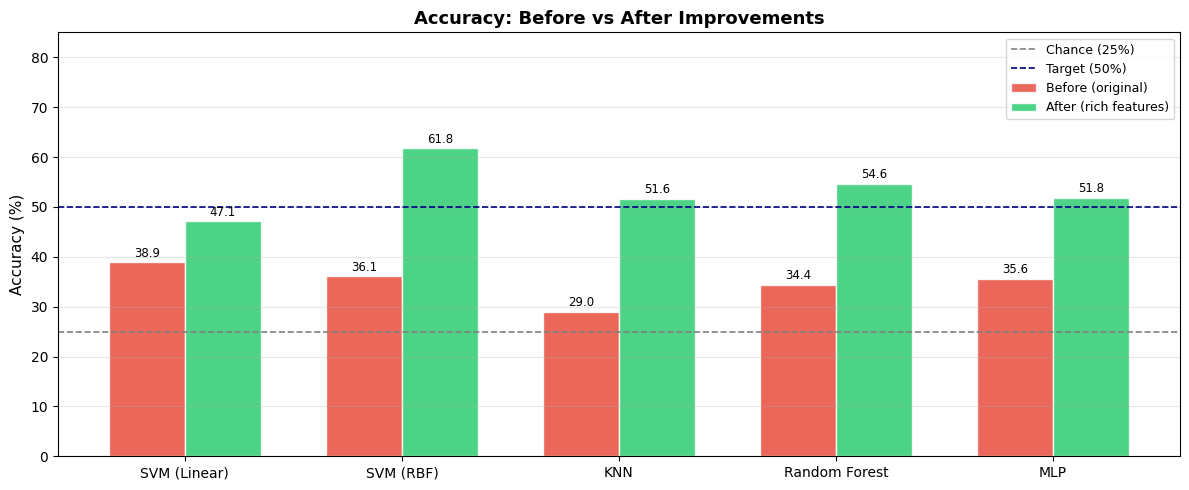

✅ Saved → before_vs_after.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL G — Before vs After comparison bar chart
# ══════════════════════════════════════════════════════════════════════════════

old_scores = {
    'SVM (Linear)' : 38.89,
    'SVM (RBF)'    : 36.11,
    'KNN'          : 28.99,
    'Random Forest': 34.38,
    'MLP'          : 35.59,
}

# Map new model names to old for comparison
name_map = {
    'SVM (Linear)' : 'SVM (Linear)',
    'SVM (RBF)'    : 'SVM (RBF)',
    'KNN (k=7)'    : 'KNN',
    'Random Forest': 'Random Forest',
    'MLP'          : 'MLP',
}

shared = [n for n in cv_results if n in name_map]
x      = np.arange(len(shared))
w      = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

old_vals = [old_scores[name_map[n]]                        for n in shared]
new_vals = [np.mean([f['acc'] for f in cv_results[n]])*100 for n in shared]

b1 = ax.bar(x - w/2, old_vals, w, label='Before (original)',
            color='#E74C3C', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, new_vals, w, label='After (rich features)',
            color='#2ECC71', alpha=0.85, edgecolor='white')

for bar, val in zip(b1, old_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8.5)
for bar, val in zip(b2, new_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8.5)

ax.axhline(25, color='gray', ls='--', lw=1.2, label='Chance (25%)')
ax.axhline(50, color='navy', ls='--', lw=1.2, label='Target (50%)')
ax.set_xticks(x)
ax.set_xticklabels([name_map[n] for n in shared], fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_ylim(0, 85)
ax.set_title('Accuracy: Before vs After Improvements',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('before_vs_after.png', dpi=110, bbox_inches='tight')
plt.show()
print('✅ Saved → before_vs_after.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL H — Grid-search tuning for the best model
# ══════════════════════════════════════════════════════════════════════════════

import copy

# ── Detect best model ──────────────────────────────────────────────────────
best_name_gs = max(cv_results,
                   key=lambda m: np.mean([f['acc'] for f in cv_results[m]]))
print(f'Tuning: {best_name_gs}')

# ── Param grids per model type ────────────────────────────────────────────
PARAM_GRIDS = {
    'SVM (Linear)' : {'clf__C': [0.1, 0.5, 1.0, 2.0]},
    'SVM (RBF)'    : {'clf__C': [1, 5, 10, 20], 'clf__gamma': ['scale', 'auto']},
    'KNN (k=7)'    : {'clf__n_neighbors': [5, 7, 11, 15], 'clf__metric': ['euclidean', 'cosine']},
    'Random Forest': {'clf__n_estimators': [200, 300], 'clf__max_depth': [15, 20, None]},
    'MLP'          : {'clf__hidden_layer_sizes': [(128, 64), (256, 128), (256, 128, 64)]},
    'Gradient Boost': {'clf__n_estimators': [100, 200], 'clf__max_depth': [4, 5, 6]},
    'XGBoost'       : {'clf__n_estimators': [200, 300], 'clf__max_depth': [5, 6],
                       'clf__learning_rate': [0.05, 0.1]},
}

if best_name_gs in PARAM_GRIDS:
    base_pipe  = copy.deepcopy(PIPELINES[best_name_gs])
    param_grid = PARAM_GRIDS[best_name_gs]

    gs = GridSearchCV(
        estimator  = base_pipe,
        param_grid = param_grid,
        cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring    = 'accuracy',
        n_jobs     = -1,
        verbose    = 1,
    )

    print(f'Grid: {param_grid}')
    gs.fit(X_rich, y_ov)

    print(f'\n✅ Best params : {gs.best_params_}')
    print(f'   Best CV acc : {gs.best_score_*100:.2f}%')
    BEST_PIPE = gs.best_estimator_
else:
    print(f'No grid defined for {best_name_gs} — using as-is')
    BEST_PIPE = copy.deepcopy(PIPELINES[best_name_gs])
    BEST_PIPE.fit(X_rich, y_ov)

Tuning: SVM (RBF)
Grid: {'clf__C': [1, 5, 10, 20], 'clf__gamma': ['scale', 'auto']}
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Best params : {'clf__C': 10, 'clf__gamma': 'auto'}
   Best CV acc : 61.82%
